In [27]:
import dotenv
import json
import os
import pickle as pkl
from typing import TypedDict, Literal, Any
from datetime import date, datetime, timedelta
from itertools import product

import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from alpha_vantage import timeseries
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import yfinance as yf
import polygon as pg

In [2]:
schema = {
    'contractID': 'str',                     # String
    'symbol': 'str',                         # String
    'expiration': 'datetime',                # Date (should be a datetime)
    'strike': 'float',                       # Float
    'type': 'category',                      # "call" or "put", can be treated as category
    'last': 'float',                         # Float
    'mark': 'float',                         # Float
    'bid': 'float',                          # Float
    'bid_size': 'int',                       # Integer
    'ask': 'float',                          # Float
    'ask_size': 'int',                       # Integer
    'volume': 'int',                         # Integer
    'open_interest': 'int',                  # Integer
    'date': 'datetime',                      # Date (should be a datetime)
    'implied_volatility': 'float',           # Float
    'delta': 'float',                        # Float
    'gamma': 'float',                        # Float
    'theta': 'float',                        # Float
    'vega': 'float',                         # Float
    'rho': 'float'                           # Float
}

numeric_columns = [
    'strike', 'last', 'mark', 'bid', 'bid_size', 'ask', 'ask_size',
    'volume', 'open_interest', 'implied_volatility', 'delta', 'gamma',
    'theta', 'vega', 'rho'
]

In [4]:
def to_date(s: str) -> date:
    return date(*map(int, s.split("-")))

In [5]:
with open("dump.json", "r") as f:
    data = json.load(f)
    data = pd.DataFrame(data['data'])

    for column, dtype in schema.items():
        if dtype == 'int':
            data[column] = pd.to_numeric(data[column], errors='coerce', downcast='integer')
        elif dtype == 'float':
            data[column] = pd.to_numeric(data[column], errors='coerce', downcast='float')
        elif dtype == 'datetime':
            data[column] = pd.to_datetime(data[column], errors='coerce')
        elif dtype == 'category':
            data[column] = data[column].astype('category')
        elif dtype == 'str':
            data[column] = data[column].astype(str)

    data = data[data['bid_size'] > 0]

In [26]:
data = data[data['type'] == 'call']
# predictors = data.select_dtypes(include=[np.number]).columns.tolist()
predictors = numeric_columns.copy()
predictors.remove('implied_volatility')
data_X = data[predictors].to_numpy()
data_y = data['implied_volatility'].to_numpy()

print(f"Training model with {predictors}")
X_train, X_test, y_train, y_test = train_test_split(
    data_X, data_y, test_size=0.2, random_state=42
)

regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)

y_pred = regr.predict(X_test)

print("Coefficients: \n", regr.coef_)
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

# Plot outputs
# plt.scatter(X_test[:, 8], y_test, color="black")
# plt.plot(X_test[:, 8], y_pred, color="blue", linewidth=3)
#
# plt.xticks(())
# plt.yticks(())

# plt.show()

Training model with ['strike', 'last', 'mark', 'bid', 'bid_size', 'ask', 'ask_size', 'volume', 'open_interest', 'delta', 'gamma', 'theta', 'vega', 'rho']
Coefficients: 
 [-2.99410429e-04  1.23228328e-02  2.10774350e+00 -1.08378255e+00
 -4.36406641e-04 -1.01900744e+00  1.63042801e-04  2.07300182e-05
  2.67382711e-06 -1.01095505e-01 -2.71785975e+00 -5.84925950e-01
  3.94296855e-01 -4.51581478e-01]
Mean squared error: 0.15
Coefficient of determination: 0.59


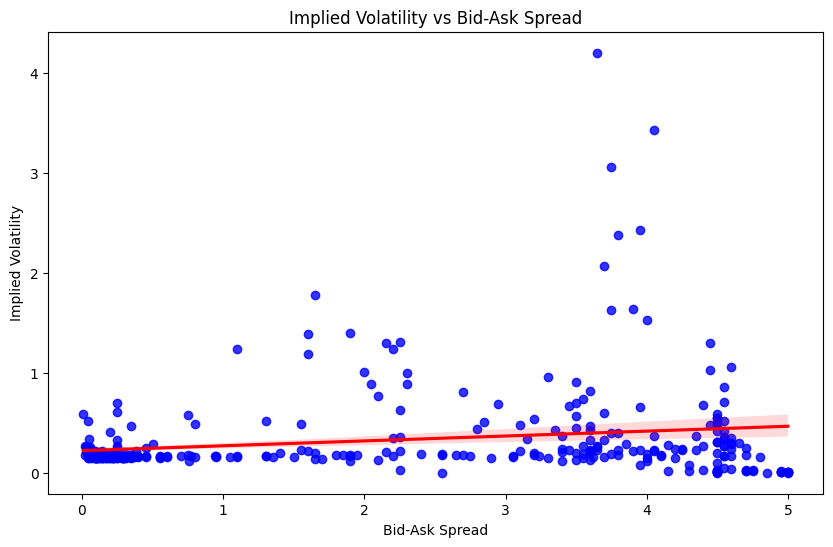

In [27]:
data['spread'] = data['ask'] - data['bid']
dt = data[(data['bid_size'] > 0) & (data['ask_size'] > 0)]

# Scatterplot with line of best fit
plt.figure(figsize=(10, 6))
sns.regplot(x='spread', y='implied_volatility', data=dt, scatter=True, color='blue', line_kws={"color": "red"})
# sns.lmplot(x='spread', y='implied_volatility', hue='type', data=data,
#                palette='Set1', height=6, aspect=1.6, scatter_kws={'s': 50},
#                line_kws={'linewidth': 2})
plt.xlabel('Bid-Ask Spread')
plt.ylabel('Implied Volatility')
plt.title('Implied Volatility vs Bid-Ask Spread')
plt.show()

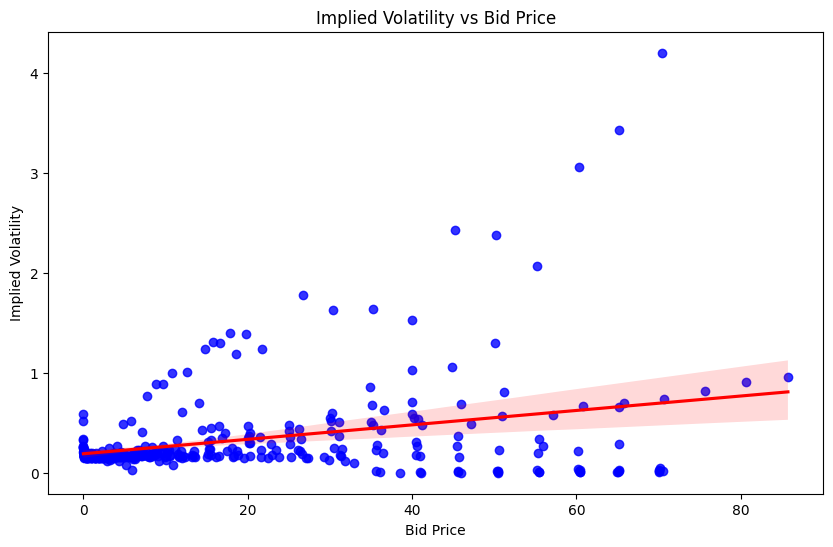

In [28]:
# Scatterplot with line of best fit
plt.figure(figsize=(10, 6))
sns.regplot(x=data['bid'], y=data['implied_volatility'], scatter=True, color='blue', line_kws={"color": "red"})
plt.xlabel('Bid Price')
plt.ylabel('Implied Volatility')
plt.title('Implied Volatility vs Bid Price')
plt.show()

In [6]:
import functools

@functools.lru_cache
def get_predictors(symbol, date):
    ticker = yf.Ticker(symbol)
    start_date = date - timedelta(days=14)
    hist = ticker.history(interval="1d", start=start_date, end=date)
    
    log_returns = np.log(hist['Close'] / hist['Close'].shift(1))
    
    return {
        "volume": hist["Volume"].mean(),
        "historial_volatility": log_returns.std() * np.sqrt(252),
        "avg_stock_price": np.mean(hist['Close']),
    }

get_predictors('aapl', datetime.now())

{'volume': np.float64(38652975.2),
 'historial_volatility': np.float64(0.19192585570914938),
 'avg_stock_price': np.float64(232.4135498046875)}

In [7]:
# compute training data
train_data = [] # [(symbol, date, actual volatility)]

stocks = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'NVDA', 'NFLX', 'V', 'JPM', 'UNH', 'PG', 'DIS', 'VZ', 
    'INTC', 'CSCO', 'PYPL', 'PEP', 'KO', 'XOM', 'CVX', 'NKE', 'LLY', 'MRK', 'PFE', 'BA', 'WMT', 'MA', 'ORCL', 
    'ADBE', 'T', 'GS', 'HD', 'C', 'MCD', 'QCOM', 'IBM', 'HON', 'ABBV', 'LMT', 'AMGN', 'TMO', 'MDT', 'RTX', 'COST', 
    'LOW', 'TXN', 'MO', 'SBUX', 'DHR', 'AXP', 'SPG', 'MMM', 'UPS', 'BK', 'BLK', 'CAT', 'FDX', 'JNJ', 'GE',
    'MMM', 'CRM', 'AMD', 'F', 'GM', 'ZTS', 'NOW', 'PANW', 'SHOP', 'ADP', 'CSX', 'PLTR', 'SPCE', 'BABA', 
    'PINS', 'SQ', 'UBER', 'LYFT', 'DKNG', 'ROKU', 'ZM', 'DOCU', 'SNOW', 'TWLO', 'TTD', 'PDD', 'BIDU', 'JD', 'NTES'
]
start_date = datetime.now() - timedelta(days=2*365)
dates = [start_date + timedelta(days=i) for i in range(0, 2*365-30, 50)]

dataset = list(product(stocks, dates))

import functools

@functools.lru_cache
def get_historical_volatility(symbol, start, end):
    ticker = yf.Ticker(symbol)
    stock_data = ticker.history(interval="1d", start=start, end=end)

    log_returns = np.log(stock_data['Close'] / stock_data['Close'].shift(1))

    return log_returns.std() * np.sqrt(252)

def data_to_df(stock_date_list):
    train_data = [(stock, date, *get_predictors(stock, date).values(), get_historical_volatility(stock, date, date + timedelta(days=7))) for stock, date in stock_date_list]
    return pd.DataFrame(train_data, columns=['Stock', 'Date', 'Volume', 'Historical Volatility', 'Stock Price', 'Volatility']).dropna()

In [8]:
training_df = data_to_df(dataset)

In [9]:
training_df['Log Volatility'] = np.log(training_df['Volatility'])

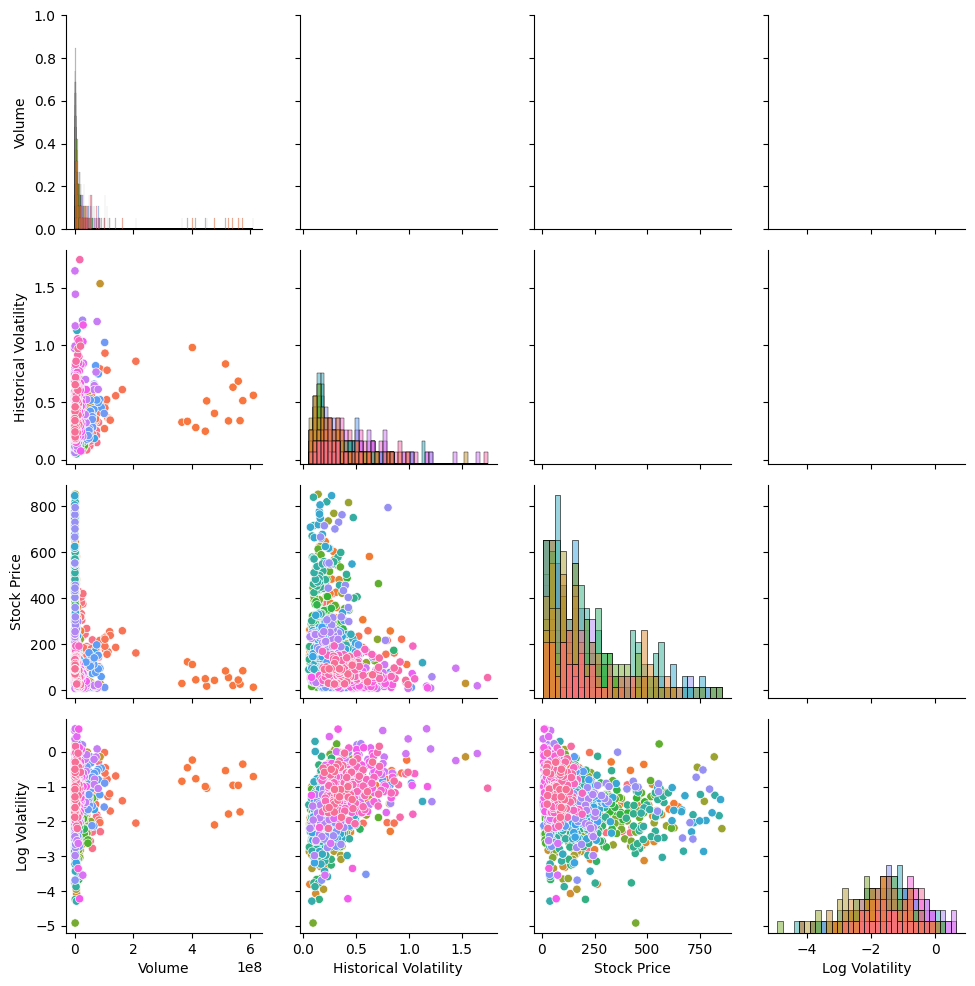

In [10]:
g = sns.PairGrid(training_df, vars=['Volume', 'Historical Volatility', 'Stock Price', 'Log Volatility'], hue='Stock')
g.map_diag(sns.histplot)
g.map_lower(sns.scatterplot)
plt.savefig("log_volatility_pair.png")

In [12]:
data_X = training_df[['Volume', 'Historical Volatility', 'Stock Price']]
data_y = training_df['Volatility']

X_train, X_test, y_train, y_test = train_test_split(
    data_X, data_y, test_size=0.2, random_state=42
)

regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)

# save model to file
pickler = pkl.Pickler(open("lin_regr.pkl", "wb"))
pickler.dump(regr)

print(regr.coef_, regr.intercept_)

[ 1.12613954e-10  4.33954237e-01 -9.70721813e-05] 0.161492984627084


In [23]:
y_pred = regr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
naive_err = np.mean(np.abs(np.diff(y_test)))
mase = mae / naive_err
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MASE: {mase}')
print(f'R²: {r2}')
print(f"Linear regression & {mae:.3f} & {rmse:.3f} & {mase:.3f} & {r2:.3f}")

MAE: 0.1326305925509652
RMSE: 0.19711536039191346
MASE: 0.6181086267378065
R²: 0.26844957999472596
Linear regression & 0.133 & 0.197 & 0.618 & 0.268


In [14]:
stocks = ['NVDA', 'AAPL', 'GOOG', 'TSLA', 'AMZN', 'MSFT', 'META', 'AVGO',
          'CRM', 'NFLX', 'KO', 'JPM', 'CVX', 'BA', 'WMT', 'SHEL', 'IAG',
          'BP', 'JD', 'WDS', 'BHP', 'CSL', 'SAP', 'DTE', 'LIN', 'SHOP',
          'ENB', 'TD', 'BNS', 'CNQ']
date = datetime(2024, 9, 12)  # TODO: check date is correct

stockdata_df = data_to_df(zip(stocks, [date] * len(stocks)))

stockdata_df['Predictions'] = regr.predict(stockdata_df[['Volume', 'Historical Volatility', 'Stock Price']])

stockdata_df[['Stock', 'Date', 'Predictions']].to_csv('actual_predictions.csv', index=False)

In [28]:
# Create linear regression object
ridge_regr = linear_model.Lasso(alpha=0.05)

# Train the model using the training sets
ridge_regr.fit(X_train, y_train)

print(ridge_regr.coef_, ridge_regr.intercept_)

ridge_y_pred = regr.predict(X_test)

mae = mean_absolute_error(y_test, ridge_y_pred)
mse = mean_squared_error(y_test, ridge_y_pred)
rmse = np.sqrt(mse)
naive_err = np.mean(np.abs(np.diff(y_test)))
mase = mae / naive_err
r2 = r2_score(y_test, ridge_y_pred)

# Print results
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MASE: {mase}')
print(f'R²: {r2}')
print(f"\t\tRidge regression & {mae:.3f} & {rmse:.3f} & {mase:.3f} & {r2:.3f}\\")

[ 3.62357609e-10  0.00000000e+00 -2.09386189e-04] 0.3028267499426349
MAE: 0.1326305925509652
RMSE: 0.19711536039191346
MASE: 0.6181086267378065
R²: 0.26844957999472596
		Ridge regression & 0.133 & 0.197 & 0.618 & 0.268\


MAE: 0.12941687818155556
RMSE: 0.19391025344941695
MASE: 0.6031315046621434
R²: 0.29204626844681214
Gradient Boosting & 0.129 & 0.194 & 0.603 & 0.292\\


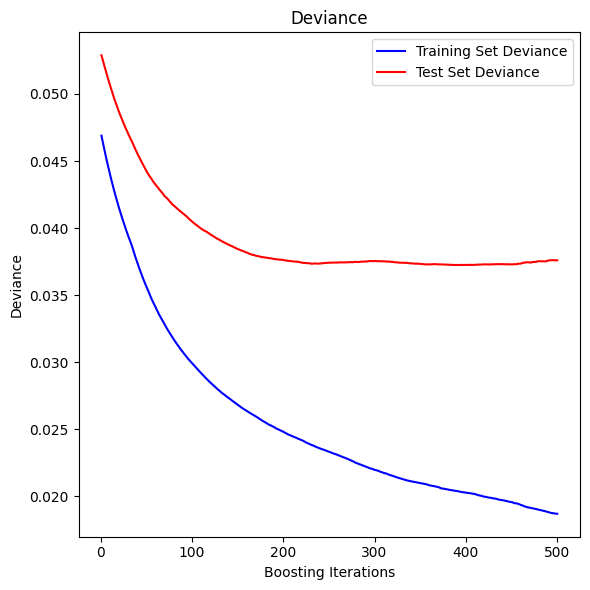

In [37]:
# gradient boost
import sklearn.ensemble as ensemble

params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}

gb_regr = ensemble.GradientBoostingRegressor(**params)
gb_regr.fit(X_train, y_train)

gb_y_pred = gb_regr.predict(X_test)

pickler = pkl.Pickler(open("gradient_boost_regr.pkl", "wb"))
pickler.dump(gb_regr)

mae = mean_absolute_error(y_test, gb_y_pred)
mse = mean_squared_error(y_test, gb_y_pred)
rmse = np.sqrt(mse)
naive_err = np.mean(np.abs(np.diff(y_test)))
mase = mae / naive_err
gbr2 = r2_score(y_test, gb_y_pred)

# Print results
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MASE: {mase}')
print(f'R²: {gbr2}')
print(f"Gradient Boosting & {mae:.3f} & {rmse:.3f} & {mase:.3f} & {gbr2:.3f}\\\\")

test_score = np.zeros((params["n_estimators"],), dtype=np.float64)
for i, y_pred in enumerate(gb_regr.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Deviance")
plt.plot(
    np.arange(params["n_estimators"]) + 1,
    gb_regr.train_score_,
    "b-",
    label="Training Set Deviance",
)
plt.plot(
    np.arange(params["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance")
fig.tight_layout()
plt.show()

In [36]:
import sklearn.neighbors as neighbors
from sklearn.preprocessing import StandardScaler

# Create knn regression object
knn_regr = neighbors.KNeighborsRegressor(n_neighbors=5, weights='distance', p=2)

# Create scaler
scaler = StandardScaler()

# scale data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model using the training sets
knn_regr.fit(X_train_scaled, y_train)

knn_y_pred = knn_regr.predict(X_test_scaled)

pickler = pkl.Pickler(open("knn_regr.pkl", "wb"))
pickler.dump(knn_regr)

print(knn_y_pred)

mae = mean_absolute_error(y_test, knn_y_pred)
mse = mean_squared_error(y_test, knn_y_pred)
rmse = np.sqrt(mse)
naive_err = np.mean(np.abs(np.diff(y_test)))
mase = mae / naive_err
r2 = r2_score(y_test, knn_y_pred)

# Print results
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MASE: {mase}')
print(f'R²: {r2}')
print(f"KNN & {mae:.3f} & {rmse:.3f} & {mase:.3f} & {gbr2:.3f}\\\\")

[0.21423234 0.51997584 0.09639984 0.27002105 0.26877636 0.25468315
 0.11933765 0.16212493 0.21107242 0.2346786  0.20110116 0.12559828
 0.3810571  0.51640977 0.4273359  0.27688982 0.17687519 0.23741763
 0.25503446 0.2079333  0.33735001 0.3890735  0.4311924  0.17578153
 0.10637448 0.40170548 0.14900687 0.38669173 0.19267112 0.38194984
 0.52054667 0.22755821 0.17411735 0.13470006 0.15214172 0.13870508
 0.64383368 0.08311648 0.39802901 0.30358577 0.23655614 0.19673748
 0.14208561 0.48341061 0.35705334 0.1025439  0.25582835 0.425932
 0.34975068 0.30039225 0.10510421 0.26185097 0.15768519 0.51535448
 0.12996454 0.42042559 0.30770401 0.17526769 0.21330683 0.22721563
 0.30466912 0.14286557 0.44108846 0.24409162 0.14958884 0.16215177
 0.2550349  0.54613335 0.3786212  0.41566957 0.22435947 0.29034006
 0.35675352 0.44723489 0.75355877 0.13398142 0.50722346 0.11004718
 0.46415753 0.09542623 0.48992317 0.31462601 0.38667774 0.12842084
 0.12939317 0.08316857 0.45711407 0.42041066 0.17759984 0.592619

In [35]:
rf_regr = ensemble.RandomForestRegressor(n_estimators=200)
rf_regr.fit(X_train_scaled, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_y_pred = rf_regr.predict(X_test_scaled)

pickler = pkl.Pickler(open("rand_forest_regr.pkl", "wb"))
pickler.dump(rf_regr)

mae = mean_absolute_error(y_test, rf_y_pred)
mse = mean_squared_error(y_test, rf_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_y_pred)
naive_err = np.mean(np.abs(np.diff(y_test)))
mase = mae / naive_err

# Print results
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'MASE: {mase}')
print(f'R²: {r2}')
print(f"Random Forest & {mae:.3f} & {rmse:.3f} & {mase:.3f} & {r2:.3f}\\\\")

MAE: 0.12651549854483046
RMSE: 0.19015261274910703
MASE: 0.5896099803410327
R²: 0.3192182240971956
Random Forest & 0.127 & 0.190 & 0.590 & 0.319\\


In [39]:
training_df.to_csv("analysis_dataset.csv")